# Fake Job Posting Prediction

#### This project uses data provided from Kaggle. This data contains features that define a job posting. These job postings are categorized as either real or fake. Fake job postings are a very small fraction of this dataset. That is as excepted. We do not expect a lot of fake jobs postings. This project follows five stages. The five stages adopted for this project are –

#### 1. Problem Definition (Project Overview, Project statement and Metrics)
#### 2. Data Collection
#### 3. Data cleaning, exploring and pre-processing
#### 4. Modeling
#### 5. Evaluating

#### The rapid growth of online job portals has made job searching easier, but it has also led to a significant increase in fake and fraudulent job postings. These fake postings mislead job seekers, waste their time, and may result in financial loss or identity theft. Manually identifying such fraudulent job advertisements is inefficient and impractical due to the large volume of job data generated daily. There is a need for an automated and accurate system that can analyze job posting content and classify it as real or fake.

#### This project uses data from Kaggle.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
w.filterwarnings ("ignore")

In [29]:
df = pd.read_csv("fake_job_postings.csv")
df.shape

(17880, 18)

In [30]:
df.head(10)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
5,6,Accounting Clerk,"US, MD,",NaN,NaN,NaN,Job OverviewApex is an environmental consultin...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,0
6,7,Head of Content (m/f),"DE, BE, Berlin",ANDROIDPIT,20000-28000,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,1,1,Full-time,Mid-Senior level,Master's Degree,Online Media,Management,0
7,8,Lead Guest Service Specialist,"US, CA, San Francisco",NaN,NaN,Airenvy’s mission is to provide lucrative yet ...,Who is Airenvy?Hey there! We are seasoned entr...,"Experience with CRM software, live chat, and p...",Competitive Pay. You'll be able to eat steak e...,0,1,1,NaN,NaN,NaN,NaN,NaN,0
8,9,HP BSM SME,"US, FL, Pensacola",NaN,NaN,Solutions3 is a woman-owned small business who...,Implementation/Configuration/Testing/Training ...,MUST BE A US CITIZEN.An active TS/SCI clearanc...,NaN,0,1,1,Full-time,Associate,NaN,Information Technology and Services,NaN,0
9,10,Customer Service Associate - Part Time,"US, AZ, Phoenix",NaN,NaN,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,NaN,0,1,0,Part-time,Entry level,High School or equivalent,Financial Services,Customer Service,0


In [31]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')

Fraudlent Distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64


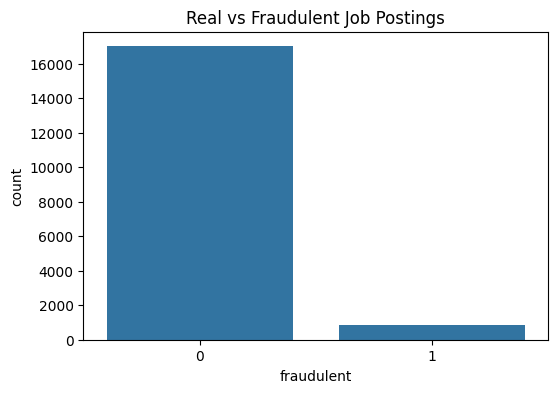

In [32]:
# Let's check the distribution of the target variable.

print("Fraudlent Distribution:")
print(df.fraudulent.value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df)
plt.title('Real vs Fraudulent Job Postings')
plt.show()

In [66]:
# Show all fraudulent jobs
fraud_jobs = df[df["fraudulent"] == 1]

In [68]:
fraud_jobs.benefits.value_counts()

benefits
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [71]:
fraud_jobs.location.value_counts()

location
US, TX, Houston        92
AU, NSW, Sydney        31
US, ,                  28
US, CA, Bakersfield    24
US, CA, Los Angeles    23
                       ..
US, LA, Slidell         1
AU, NSW,                1
GB, LIN, Immingham      1
US, , chicago           1
US, MI, DETROIT         1
Name: count, Length: 374, dtype: int64

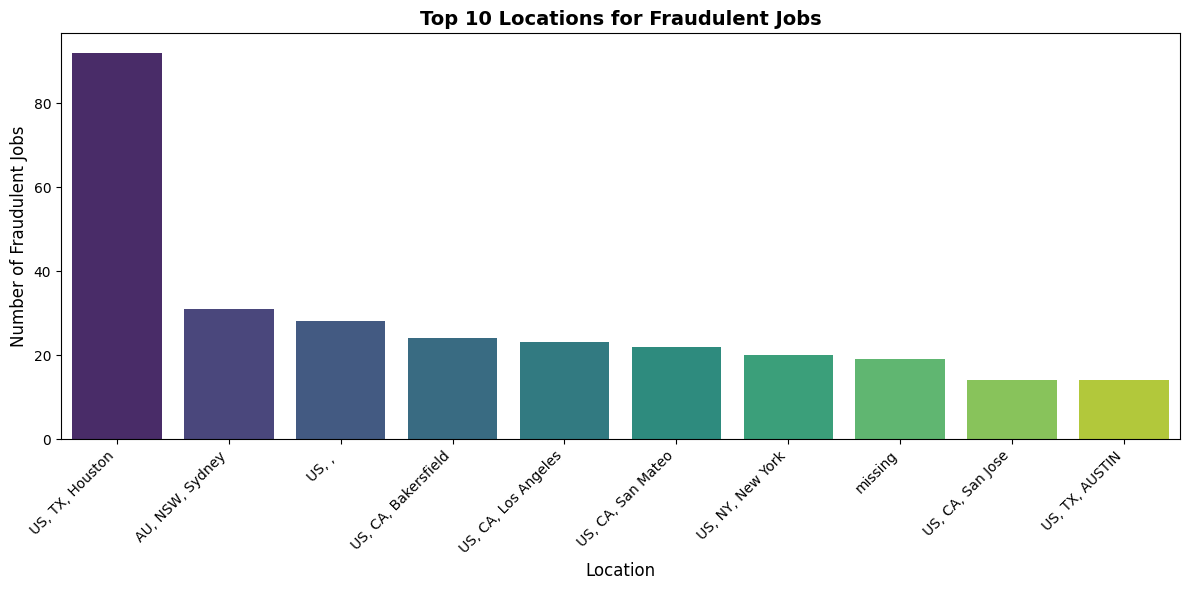

In [73]:

# Top 10 locations
top_10_locations = fraud_jobs['location'].value_counts().head(10).reset_index()
top_10_locations.columns = ['location', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_locations, x='location', y='count', palette='viridis')
plt.title('Top 10 Locations for Fraudulent Jobs', fontsize=14, fontweight='bold')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Number of Fraudulent Jobs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Most of the fraud jobs are posted from USA and the maximum no. of fraud_job posting was from Houston, that's definetely need to be checked.

In [ ]:
# Dropped department and salary_range as it had more than 50% missing values.
null_col=['department','salary_range']
df.drop(null_col,axis=1,inplace=True)

In [34]:
df.isnull().sum() / len(df)*100

job_id                  0.000000
title                   0.000000
location                1.935123
company_profile        18.501119
description             0.005593
requirements           15.078300
benefits               40.335570
telecommuting           0.000000
has_company_logo        0.000000
has_questions           0.000000
employment_type        19.412752
required_experience    39.429530
required_education     45.329978
industry               27.421700
function               36.101790
fraudulent              0.000000
dtype: float64

In [36]:
# Let's bifurcate the columns based on text, category and numeric features.

text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
cat_columns = ['location', 'employment_type','required_experience', 'required_education', 'industry', 'function']
binary_columns = ['telecommuting', 'has_company_logo', 'has_questions']

In [38]:
# Fill NaN in text columns with empty string.
for col in text_columns:
    df[col] = df[col].fillna('')

In [39]:
# Combining all text into one column.
df['full_text'] = df[text_columns].agg(' '.join, axis=1)

In [40]:
# Fill NaN in categorical columns
for col in cat_columns:
    df[col] = df[col].fillna('missing')

In [41]:
for col in binary_columns:
    df[col] = df[col].fillna(0)

In [42]:
df.isnull().sum()

job_id                 0
title                  0
location               0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
full_text              0
dtype: int64

# NLP Pre-Processing

In [43]:
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [44]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to C:\Users\Madhukar
[nltk_data]     Nirgun\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Madhukar
[nltk_data]     Nirgun\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to C:\Users\Madhukar
[nltk_data]     Nirgun\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [45]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Remove URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

In [46]:
print("Cleaning text...")
df['cleaned_text'] = df['full_text'].apply(clean_text)
print("Text cleaning completed.")

Cleaning text...
Text cleaning completed.


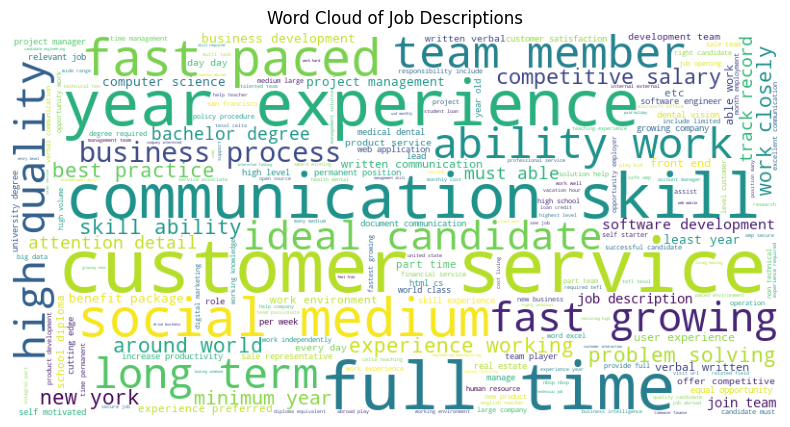

In [77]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400,
background_color='white').generate(" ".join(df['cleaned_text']))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Job Descriptions")
plt.show()

In [47]:
X_text = df['cleaned_text']
X_cat = df[cat_columns + binary_columns]
y = df['fraudulent']

# TF-IDF Vectorization for Text (max_features=5000 to avoid memory issues).

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)

In [49]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_text, X_cat, y, test_size=0.2, random_state=14, stratify=y)

In [50]:
# Transform text
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test)

In [51]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Transforming categorical and binary features.
preprocessor = ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_columns),
        ('binary', 'passthrough', binary_columns)])

In [52]:
X_cat_train_processed = preprocessor.fit_transform(X_cat_train)
X_cat_test_processed = preprocessor.transform(X_cat_test)

# Combining TF-IDF + Categorical Features.

In [53]:
from scipy.sparse import hstack

X_train = hstack([X_text_train_tfidf, X_cat_train_processed])
X_test = hstack([X_text_test_tfidf, X_cat_test_processed])

# Convert to dense 
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

print("Final feature matrix shape:", X_train_dense.shape)

Final feature matrix shape: (14304, 7970)


In [54]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5254573506722504), np.int64(1): np.float64(10.32034632034632)}


# Building Neural Network Model.

In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [56]:
model.compile(optimizer='adam',loss='binary_crossentropy',
              metrics=['accuracy', 'Precision', 'Recall'])

In [57]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_dense, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - Precision: 0.2851 - Recall: 0.7437 - accuracy: 0.8973 - loss: 0.3437 - val_Precision: 0.4904 - val_Recall: 0.9209 - val_accuracy: 0.9497 - val_loss: 0.1411
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - Precision: 0.5910 - Recall: 0.9675 - accuracy: 0.9660 - loss: 0.0885 - val_Precision: 0.6256 - val_Recall: 0.9137 - val_accuracy: 0.9692 - val_loss: 0.0962
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - Precision: 0.7888 - Recall: 0.9910 - accuracy: 0.9867 - loss: 0.0430 - val_Precision: 0.6882 - val_Recall: 0.9209 - val_accuracy: 0.9759 - val_loss: 0.0801
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - Precision: 0.9199 - Recall: 0.9946 - accuracy: 0.9955 - loss: 0.0195 - val_Precision: 0.8162 - val_Recall: 0.7986 - val_accuracy: 0.9815 - val_loss: 0.0750
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - Precision: 0.9261 - Recall: 0.9946 - accuracy: 0.9959 - loss: 0.0103 - val_Precision: 0.7126 - v

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_prob = model.predict(X_test_dense)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step  

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.86      0.77      0.82       173

    accuracy                           0.98      3576
   macro avg       0.93      0.88      0.90      3576
weighted avg       0.98      0.98      0.98      3576

ROC AUC Score: 0.9855618724722661


[[3382   21]
 [  39  134]]


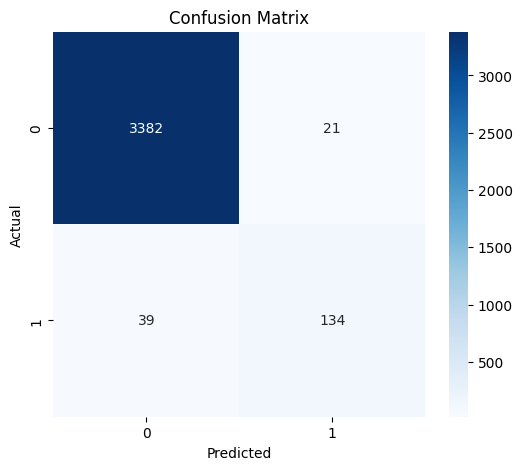

In [79]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [60]:
model.save('fraudulent_job_model.keras')
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(preprocessor, 'categorical_preprocessor.pkl')

['categorical_preprocessor.pkl']

In [78]:
test_job = {
    'title': 'Data Entry Clerk - Work From Home $5000/week',
    'location': 'missing',
    'department': 'missing',
    'salary_range': 'missing',
    'company_profile': '',
    'description': 'Easy job! Just enter data from home and get paid big money every week. No experience needed.',
    'requirements': 'Must have computer and internet. Small registration fee to start.',
    'benefits': 'Unlimited earning potential! Be your own boss!',
    'telecommuting': 1,
    'has_company_logo': 0,
    'has_questions': 0,
    'employment_type': 'missing',
    'required_experience': 'missing',
    'required_education': 'missing',
    'industry': 'missing',
    'function': 'missing'
}

# Prediction function
def predict_single_job(job_dict):
    df_new = pd.DataFrame([job_dict])
    
    # Fills missing columns
    for col in text_columns:
        df_new[col] = df_new.get(col, '').fillna('')
    for col in cat_columns:
        df_new[col] = df_new.get(col, 'missing').fillna('missing')
    for col in binary_columns:
        df_new[col] = df_new.get(col, 0).fillna(0)
    
    # Combine and clean text
    df_new['full_text'] = df_new[text_columns].agg(' '.join, axis=1)
    df_new['cleaned_text'] = df_new['full_text'].apply(clean_text)
    

    text_vec = tfidf.transform(df_new['cleaned_text'])
    cat_vec = preprocessor.transform(df_new[cat_columns + binary_columns])
    X_new = hstack([text_vec, cat_vec]).toarray()
    
    # Prediction
    prob = model.predict(X_new, verbose=0)[0][0]
    prediction = 'FRAUDULENT ⚠️' if prob > 0.5 else 'REAL ✅'
    
    return prob, prediction


probability, result = predict_single_job(test_job)

print("\n=== SINGLE SAMPLE PREDICTION ===\n")
print(f"Job Title: {test_job['title']}")
print(f"Fraud Probability: {probability:.4f}")
print(f"Final Prediction : {result}")

if probability > 0.5:
    print("\n🚨 This job posting looks highly suspicious / likely fake!")
else:
    print("\n✅ This job posting appears legitimate.")


=== SINGLE SAMPLE PREDICTION ===

Job Title: Data Entry Clerk - Work From Home $5000/week
Fraud Probability: 1.0000
Final Prediction : FRAUDULENT ⚠️

🚨 This job posting looks highly suspicious / likely fake!
